# Analisis DBSCAN Clustering Lokasi Rumah Sakit di Jawa Barat

## 1. Import Library Utama

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import folium
from folium.plugins import HeatMap, MarkerCluster
import geopandas as gpd
import contextily as ctx
from shapely.geometry import Point
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

## 2. Load Data Rumah Sakit

In [ ]:
# Load dataset
df = pd.read_csv('../../Data/rumah_sakit.csv')

print(f"Jumlah data: {len(df)} rumah sakit")
print(f"\nKolom dataset:")
print(df.columns.tolist())

df.head(10)

Jumlah data: 16944 rumah sakit

Kolom dataset:
['Date', 'Time (UTC)', 'City', 'Country', 'Latitude', 'Longitude', 'Earthquake Magnitude', 'Depth (km)', 'Impact Score']


,Date,Time (UTC),City,Country,Latitude,Longitude,Earthquake Magnitude,Depth (km),Impact Score
0,2025-03-15,16:28:36,55 km NNW of Finschhafen,Papua New Guinea,-6.1233,147.5932,5.1,59.033,400
1,2025-03-15,03:19:27,5 km ESE of San Miguel Achiutla,Mexico,17.2871,-97.4400,5.6,63.551,503
2,2025-03-14,23:42:35,South Sandwich Islands region,South Sandwich Islands region,-55.7385,-27.1122,6.0,35.379,554
3,2025-03-14,19:37:15,15 km NNE of Lesina,Italy,41.9788,15.4490,5.0,8.742,389
4,2025-03-14,11:13:32,229 km N of Palu,Indonesia,1.1364,120.2317,5.4,26.072,449
5,2025-03-13,22:04:45,89 km NNE of Ambler,Alaska,67.8308,-157.0621,5.1,9.800,400
6,2025-03-13,21:20:11,51 km SSW of Padam,India,33.0777,76.5809,5.1,56.996,431
7,2025-03-13,15:45:41,138 km NE of Lospalos,Timor Leste,-7.5648,127.8120,5.0,158.207,385
8,2025-03-13,05:09:40,96 km S of Hualien City,Taiwan,23.1142,121.4919,5.2,27.312,420
9,2025-03-12,17:29:50,56 km WSW of Point Hope,Alaska,68.2130,-168.0594,5.0,38.500,385


In [3]:
# Info dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 332 entries, 0 to 331
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   332 non-null    int64 
 1   kode_provinsi        332 non-null    int64 
 2   nama_provinsi        332 non-null    object
 3   kode_kabupaten_kota  332 non-null    int64 
 4   nama_kabupaten_kota  332 non-null    object
 5   nama_rs              332 non-null    object
 6   alamat               332 non-null    object
 7   desa_kelurahan       332 non-null    object
 8   kecamatan            332 non-null    object
 9   telp_ppk             332 non-null    object
 10  latitude             332 non-null    object
 11  longitude            332 non-null    object
 12  tahun                332 non-null    int64 
dtypes: int64(4), object(9)
memory usage: 33.8+ KB


## 3. Data Cleaning (Pembersihan Data)

In [4]:
# Cek missing values
print("Missing Values:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

# Cek duplikat
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Cek data koordinat
print(f"\nMissing latitude: {df['latitude'].isnull().sum()}")
print(f"\nMissing longitude: {df['longitude'].isnull().sum()}")

Missing Values:
id                     0
kode_provinsi          0
nama_provinsi          0
kode_kabupaten_kota    0
nama_kabupaten_kota    0
nama_rs                0
alamat                 0
desa_kelurahan         0
kecamatan              0
telp_ppk               0
latitude               0
longitude              0
tahun                  0
dtype: int64

Total missing values: 0

Duplicate rows: 0

Missing latitude: 0

Missing longitude: 0


In [5]:
# Fungsi untuk konversi string ke float (menangani koma sebagai desimal)
def convert_to_float(value):
    if pd.isna(value):
        return value
    if isinstance(value, (int, float)):
        return float(value)
    # Konversi string, ganti koma dengan titik
    str_value = str(value).replace(',', '.')
    try:
        return float(str_value)
    except:
        return np.nan

# Konversi kolom latitude dan longitude
df['latitude'] = df['latitude'].apply(convert_to_float)
df['longitude'] = df['longitude'].apply(convert_to_float)

# Hapus data dengan koordinat yang hilang atau invalid
df_clean = df.dropna(subset=['latitude', 'longitude'])

print(f"Data setelah pembersihan: {len(df_clean)} rumah sakit")
print(f"Data yang dihapus: {len(df) - len(df_clean)} rumah sakit")

# Reset index
df_clean = df_clean.reset_index(drop=True)
df_clean.head()

Data setelah pembersihan: 332 rumah sakit
Data yang dihapus: 0 rumah sakit


,id,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,nama_rs,alamat,desa_kelurahan,kecamatan,telp_ppk,latitude,longitude,tahun
0,1,32,JAWA BARAT,3204,KABUPATEN BANDUNG,RSUD CICALENGKA,"JL. H. DARHAM CIKOPO NO.35, TENJOLAYA, KEC. CI...",TENJOLAYA,CICALENGKA,022-7952202,-6.982337,107.842052,2019
1,2,32,JAWA BARAT,3204,KABUPATEN BANDUNG,RSUD AL IHSAN,"JL. KI ASTRAMANGGALA, BALEENDAH, KEC. BALEENDA...",BALEENDAH,BALEENDAH,022-5940872,-7.007707,107.624064,2019
2,3,32,JAWA BARAT,3204,KABUPATEN BANDUNG,RSUD MAJALAYA,"JL. CIPAKU NO.87, CIPAKU, KEC. PASEH, BANDUNG,...",CIPAKU,PASEH,022-5950035,-7.049290,107.772000,2019
3,4,32,JAWA BARAT,3204,KABUPATEN BANDUNG,RSUD SOREANG,"JL. ALUN-ALUN UTARA NO.1, PAMEKARAN, KEC. SORE...",PAMEKARAN,SOREANG,022-5891355,-7.030000,108.000000,2019
4,5,32,JAWA BARAT,3217,KABUPATEN BANDUNG BARAT,RSUD CIKALONG WETAN,"JL. CIKALONG NO.290, CIPTAGUMATI, KEC. CIKALON...",CIPTAMUGATI,CIKALONG WETAN,022-86866016,-6.743744,107.444976,2019


## 4. Exploratory Data Analysis (EDA)

### 4.1. Distribusi Rumah Sakit per Kabupaten/Kota

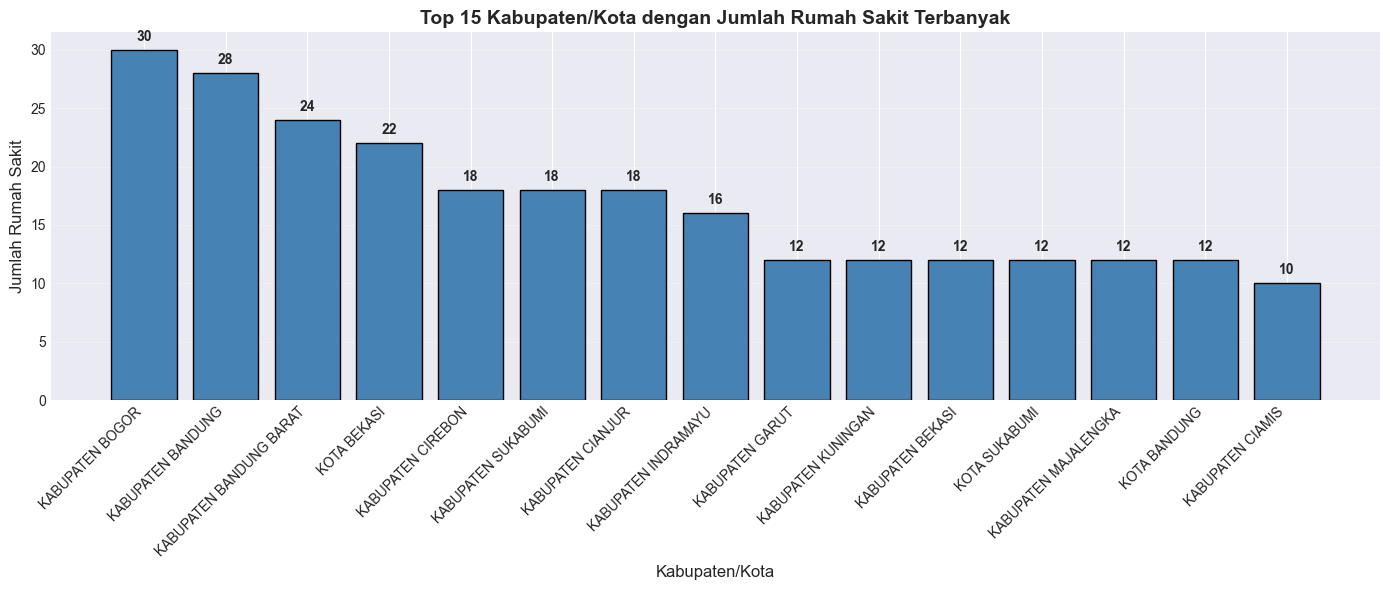


Total kabupaten/kota: 27


In [6]:
# Hitung jumlah RS per kabupaten/kota
rs_per_kab = df_clean['nama_kabupaten_kota'].value_counts().head(15)

plt.figure(figsize=(14, 6))
bars = plt.bar(range(len(rs_per_kab)), rs_per_kab.values, color='steelblue', edgecolor='black')
plt.xlabel('Kabupaten/Kota', fontsize=12)
plt.ylabel('Jumlah Rumah Sakit', fontsize=12)
plt.title('Top 15 Kabupaten/Kota dengan Jumlah Rumah Sakit Terbanyak', fontsize=14, fontweight='bold')
plt.xticks(range(len(rs_per_kab)), rs_per_kab.index, rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')

# Tambahkan nilai di atas bar
for i, v in enumerate(rs_per_kab.values):
    plt.text(i, v + 0.5, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nTotal kabupaten/kota: {df_clean['nama_kabupaten_kota'].nunique()}")

### 4.2. Konversi ke GeoDataFrame

In [7]:
# Buat geometry dari koordinat
geometry = [Point(xy) for xy in zip(df_clean['longitude'], df_clean['latitude'])]

# Buat GeoDataFrame
gdf = gpd.GeoDataFrame(df_clean, geometry=geometry, crs='EPSG:4326')

print("GeoDataFrame berhasil dibuat!")
print(f"CRS: {gdf.crs}")
print(f"\nBounds:")
print(gdf.total_bounds)

gdf.head()

GeoDataFrame berhasil dibuat!
CRS: EPSG:4326

Bounds:
[ 1.0655790e+02 -6.5381349e+07  1.0871900e+02 -6.1000000e+00]


,id,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,nama_rs,alamat,desa_kelurahan,kecamatan,telp_ppk,latitude,longitude,tahun,geometry
0,1,32,JAWA BARAT,3204,KABUPATEN BANDUNG,RSUD CICALENGKA,"JL. H. DARHAM CIKOPO NO.35, TENJOLAYA, KEC. CI...",TENJOLAYA,CICALENGKA,022-7952202,-6.982337,107.842052,2019,POINT (107.84205 -6.98234)
1,2,32,JAWA BARAT,3204,KABUPATEN BANDUNG,RSUD AL IHSAN,"JL. KI ASTRAMANGGALA, BALEENDAH, KEC. BALEENDA...",BALEENDAH,BALEENDAH,022-5940872,-7.007707,107.624064,2019,POINT (107.62406 -7.00771)
2,3,32,JAWA BARAT,3204,KABUPATEN BANDUNG,RSUD MAJALAYA,"JL. CIPAKU NO.87, CIPAKU, KEC. PASEH, BANDUNG,...",CIPAKU,PASEH,022-5950035,-7.049290,107.772000,2019,POINT (107.772 -7.04929)
3,4,32,JAWA BARAT,3204,KABUPATEN BANDUNG,RSUD SOREANG,"JL. ALUN-ALUN UTARA NO.1, PAMEKARAN, KEC. SORE...",PAMEKARAN,SOREANG,022-5891355,-7.030000,108.000000,2019,POINT (108 -7.03)
4,5,32,JAWA BARAT,3217,KABUPATEN BANDUNG BARAT,RSUD CIKALONG WETAN,"JL. CIKALONG NO.290, CIPTAGUMATI, KEC. CIKALON...",CIPTAMUGATI,CIKALONG WETAN,022-86866016,-6.743744,107.444976,2019,POINT (107.44498 -6.74374)


### 4.3. Visualisasi Peta Sebaran Rumah Sakit dengan Basemap

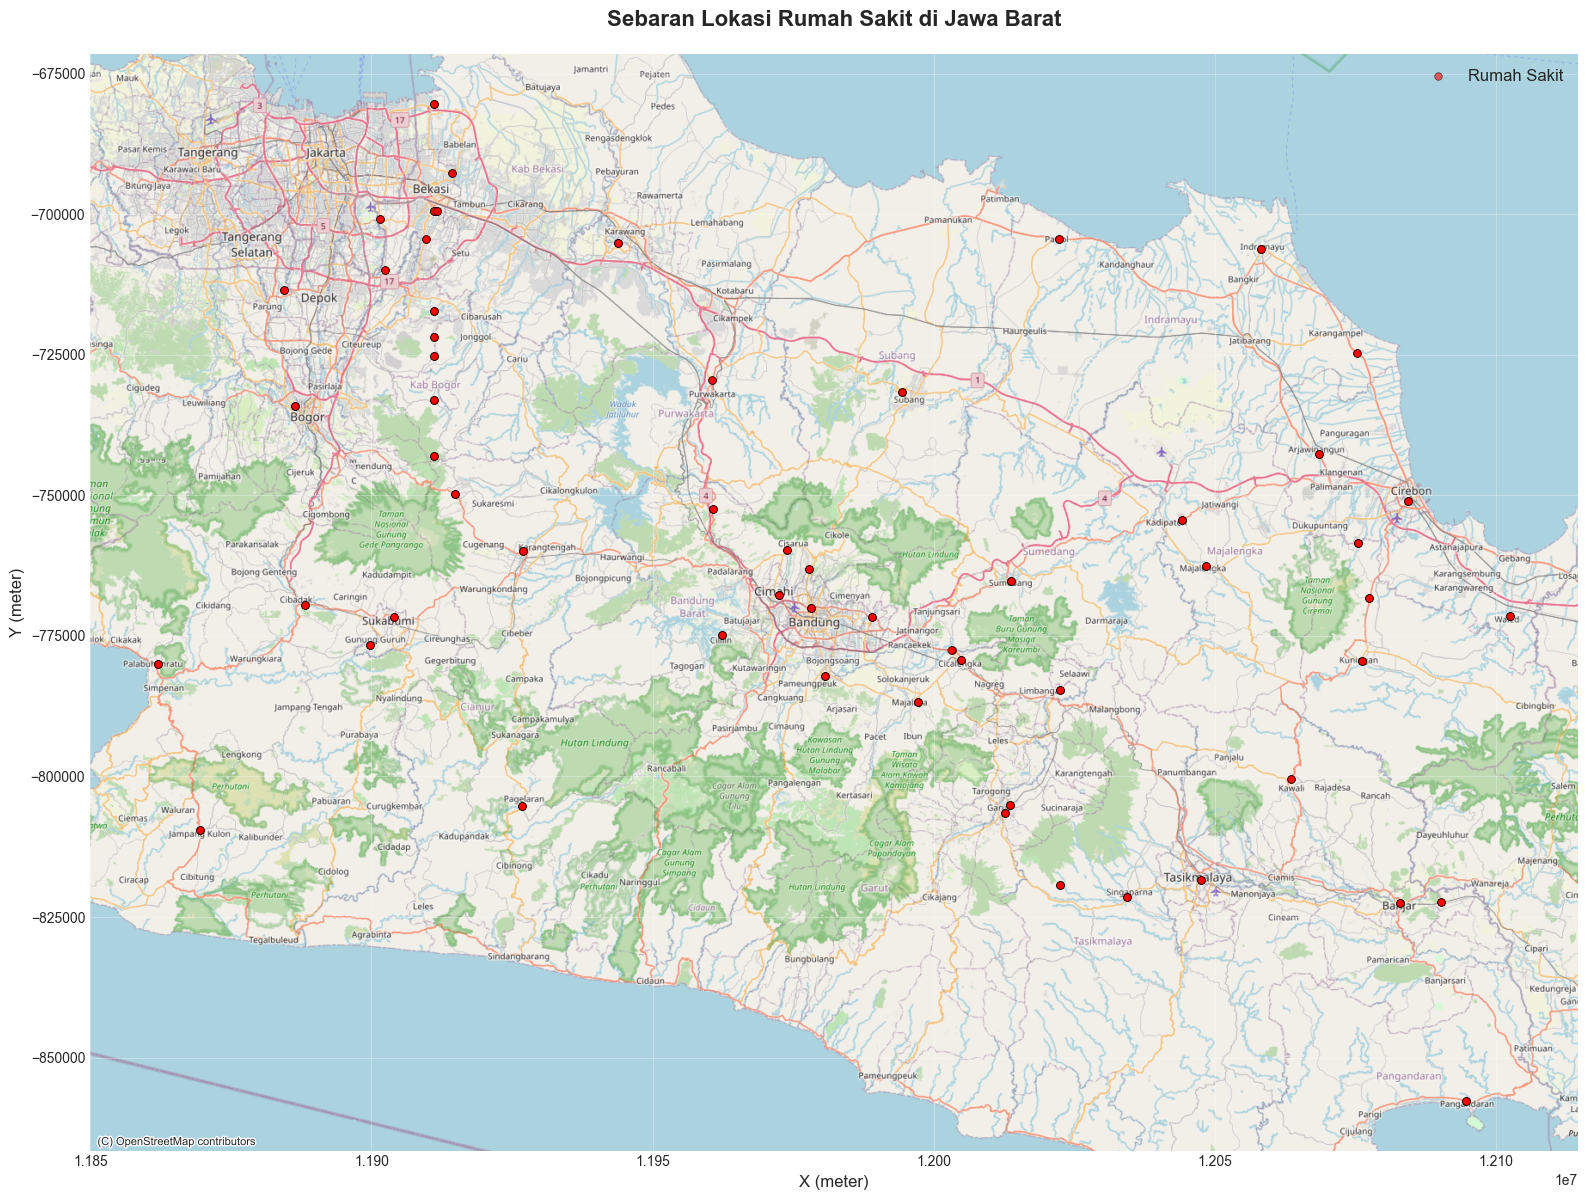

In [8]:
# Plot dengan basemap
fig, ax = plt.subplots(figsize=(16, 12))

# Konversi ke Web Mercator untuk basemap
gdf_web = gdf.to_crs(epsg=3857)

# Plot points
gdf_web.plot(ax=ax, color='red', markersize=30, alpha=0.6, edgecolor='black', linewidth=0.5, label='Rumah Sakit')

# Tambahkan basemap
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, zoom=10)

ax.set_title('Sebaran Lokasi Rumah Sakit di Jawa Barat', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('X (meter)', fontsize=12)
ax.set_ylabel('Y (meter)', fontsize=12)
ax.legend(fontsize=12, loc='upper right')
ax.grid(True, alpha=0.3)

# Set aspect ratio
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

### 4.4. Visualisasi Heatmap dengan Folium

In [9]:
# Hitung pusat peta
center_lat = df_clean['latitude'].mean()
center_lon = df_clean['longitude'].mean()

# Buat peta dasar
peta_rs = folium.Map(location=[center_lat, center_lon], zoom_start=9, tiles='OpenStreetMap')

# Data untuk heatmap
heat_data = [[row['latitude'], row['longitude']] for idx, row in df_clean.iterrows()]

# Tambahkan heatmap
HeatMap(heat_data, radius=15, blur=20, max_zoom=13, gradient={0.4: 'blue', 0.6: 'lime', 0.8: 'orange', 1: 'red'}).add_to(peta_rs)

# Tampilkan peta
peta_rs

### 4.5. Peta Interaktif dengan Marker Cluster

In [10]:
# Buat peta dengan marker cluster
peta_marker = folium.Map(location=[center_lat, center_lon], zoom_start=9, tiles='OpenStreetMap')

# Buat marker cluster
marker_cluster = MarkerCluster().add_to(peta_marker)

# Tambahkan marker
for idx, row in df_clean.iterrows():
    popup_text = f"""<b>{row['nama_rs']}</b><br>
                     Kabupaten/Kota: {row['nama_kabupaten_kota']}<br>
                     Kecamatan: {row['kecamatan']}<br>
                     Alamat: {row['alamat']}"""
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=folium.Popup(popup_text, max_width=300),
        icon=folium.Icon(color='red', icon='plus-sign')
    ).add_to(marker_cluster)

peta_marker

## 5. Preprocessing untuk DBSCAN

### 5.1. Ekstraksi Fitur Koordinat

In [11]:
# Ekstrak koordinat untuk clustering
coordinates = df_clean[['latitude', 'longitude']].values

print(f"Shape data koordinat: {coordinates.shape}")
print(f"\nSample koordinat (5 data pertama):")
print(coordinates[:5])

Shape data koordinat: (332, 2)

Sample koordinat (5 data pertama):
[[ -6.98233728 107.842052  ]
 [ -7.00770719 107.624064  ]
 [ -7.04929    107.772     ]
 [ -7.03       108.        ]
 [ -6.74374444 107.444976  ]]


### 5.2. Normalisasi Data Koordinat

In [12]:
# Normalisasi koordinat
scaler = StandardScaler()
coordinates_scaled = scaler.fit_transform(coordinates)

print("Data koordinat setelah normalisasi:")
print(f"Mean: {coordinates_scaled.mean(axis=0)}")
print(f"Std: {coordinates_scaled.std(axis=0)}")
print(f"\nSample data (5 pertama):")
print(coordinates_scaled[:5])

Data koordinat setelah normalisasi:
Mean: [ 2.67523620e-17 -1.26645682e-14]
Std: [1. 1.]

Sample data (5 pertama):
[[ 0.09549102  0.36887303]
 [ 0.09549102  0.01889036]
 [ 0.09549101  0.2564036 ]
 [ 0.09549102  0.62246067]
 [ 0.09549106 -0.26863783]]


## 6. Menentukan Parameter DBSCAN

### 6.1. K-Distance Graph untuk Menentukan Epsilon

Min samples yang disarankan: 4


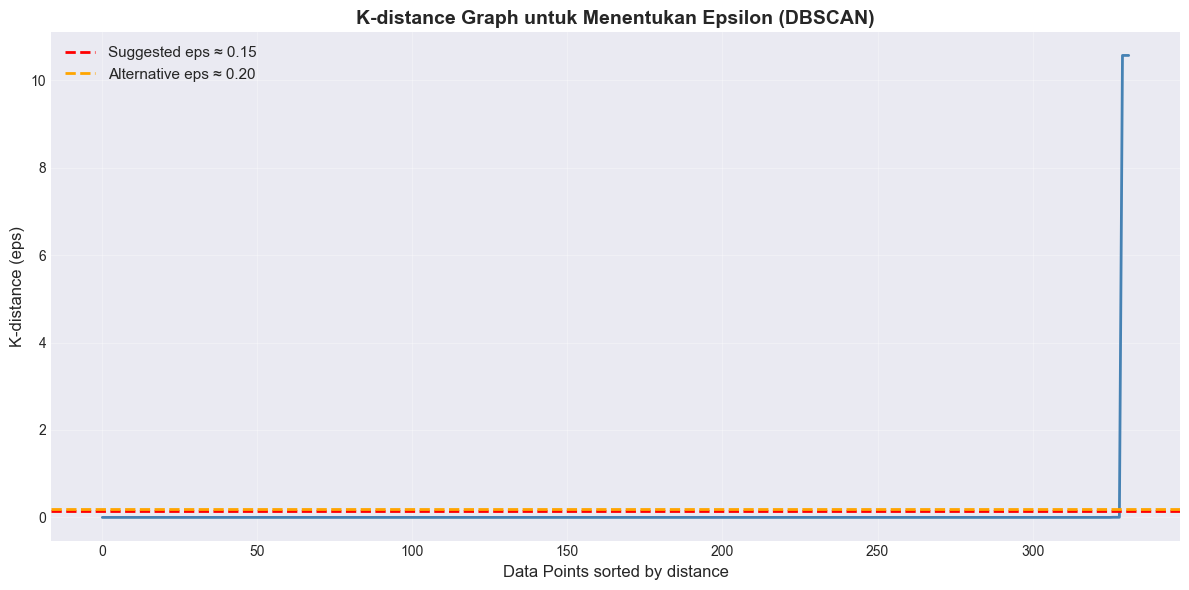


Berdasarkan grafik, eps yang disarankan sekitar 0.10 - 0.25


In [13]:
# Tentukan min_samples
min_samples = 2 * coordinates_scaled.shape[1]
print(f"Min samples yang disarankan: {min_samples}")

# Hitung jarak ke k-nearest neighbors
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(coordinates_scaled)
distances, indices = neighbors_fit.kneighbors(coordinates_scaled)

# Ambil jarak terjauh dan urutkan
distances = np.sort(distances[:, -1], axis=0)

# Plot K-distance graph
plt.figure(figsize=(12, 6))
plt.plot(distances, linewidth=2, color='steelblue')
plt.ylabel('K-distance (eps)', fontsize=12)
plt.xlabel('Data Points sorted by distance', fontsize=12)
plt.title('K-distance Graph untuk Menentukan Epsilon (DBSCAN)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Tambahkan garis saran
plt.axhline(y=0.15, color='r', linestyle='--', linewidth=2, label='Suggested eps ≈ 0.15')
plt.axhline(y=0.20, color='orange', linestyle='--', linewidth=2, label='Alternative eps ≈ 0.20')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("\nBerdasarkan grafik, eps yang disarankan sekitar 0.10 - 0.25")

## 7. Implementasi DBSCAN

In [14]:
# Terapkan DBSCAN
eps = 0.15
min_samples = 5

dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
clusters = dbscan.fit_predict(coordinates_scaled)

# Tambahkan hasil clustering
df_clean['Cluster'] = clusters
gdf['Cluster'] = clusters

# Tampilkan hasil
print("="*70)
print("HASIL CLUSTERING DBSCAN")
print("="*70)
print(f"\nParameter DBSCAN:")
print(f"  - Epsilon (eps): {eps}")
print(f"  - Min samples: {min_samples}")

n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_noise = list(clusters).count(-1)

print(f"\nHasil Clustering:")
print(f"  - Jumlah cluster: {n_clusters}")
print(f"  - Jumlah noise points: {n_noise}")
print(f"  - Persentase noise: {(n_noise/len(clusters)*100):.2f}%")

print(f"\nDistribusi Rumah Sakit per Cluster:")
cluster_dist = pd.Series(clusters).value_counts().sort_index()
for cluster_id, count in cluster_dist.items():
    if cluster_id == -1:
        print(f"  Cluster {cluster_id} (Noise/Outlier): {count} RS")
    else:
        print(f"  Cluster {cluster_id}: {count} RS")
print("="*70)

HASIL CLUSTERING DBSCAN

Parameter DBSCAN:
  - Epsilon (eps): 0.15
  - Min samples: 5

Hasil Clustering:
  - Jumlah cluster: 7
  - Jumlah noise points: 3
  - Persentase noise: 0.90%

Distribusi Rumah Sakit per Cluster:
  Cluster -1 (Noise/Outlier): 3 RS
  Cluster 0: 109 RS
  Cluster 1: 82 RS
  Cluster 2: 12 RS
  Cluster 3: 90 RS
  Cluster 4: 6 RS
  Cluster 5: 18 RS
  Cluster 6: 12 RS


## 8. Evaluasi Clustering

In [15]:
# Evaluasi clustering (tanpa noise points)
mask = clusters != -1
n_clusters_eval = len(set(clusters[mask]))

print(f"Jumlah cluster untuk evaluasi: {n_clusters_eval}")

if n_clusters_eval > 1 and mask.sum() > 0:
    silhouette = silhouette_score(coordinates_scaled[mask], clusters[mask])
    davies_bouldin = davies_bouldin_score(coordinates_scaled[mask], clusters[mask])
    calinski_harabasz = calinski_harabasz_score(coordinates_scaled[mask], clusters[mask])
    
    print("\n" + "="*70)
    print("METRIK EVALUASI CLUSTERING")
    print("="*70)
    print(f"\nSilhouette Score: {silhouette:.4f}")
    print(f"  → Range: -1 to 1 (semakin tinggi semakin baik)")
    print(f"  → Interpretasi: {'Baik' if silhouette > 0.5 else 'Cukup' if silhouette > 0.25 else 'Kurang baik'}")
    
    print(f"\nDavies-Bouldin Index: {davies_bouldin:.4f}")
    print(f"  → Semakin rendah semakin baik")
    print(f"  → Interpretasi: {'Baik' if davies_bouldin < 1 else 'Cukup' if davies_bouldin < 2 else 'Kurang baik'}")
    
    print(f"\nCalinski-Harabasz Score: {calinski_harabasz:.4f}")
    print(f"  → Semakin tinggi semakin baik")
    print("="*70)
elif n_clusters_eval == 1:
    print("\n⚠️  Hanya 1 cluster, pertimbangkan menurunkan eps atau min_samples")
else:
    print("\n⚠️  Semua data adalah noise, pertimbangkan meningkatkan eps")

Jumlah cluster untuk evaluasi: 7

METRIK EVALUASI CLUSTERING

Silhouette Score: 0.6079
  → Range: -1 to 1 (semakin tinggi semakin baik)
  → Interpretasi: Baik

Davies-Bouldin Index: 0.3323
  → Semakin rendah semakin baik
  → Interpretasi: Baik

Calinski-Harabasz Score: 979.2645
  → Semakin tinggi semakin baik


## 9. Visualisasi Hasil Clustering

### 9.1. Peta Sebaran dengan Warna Cluster

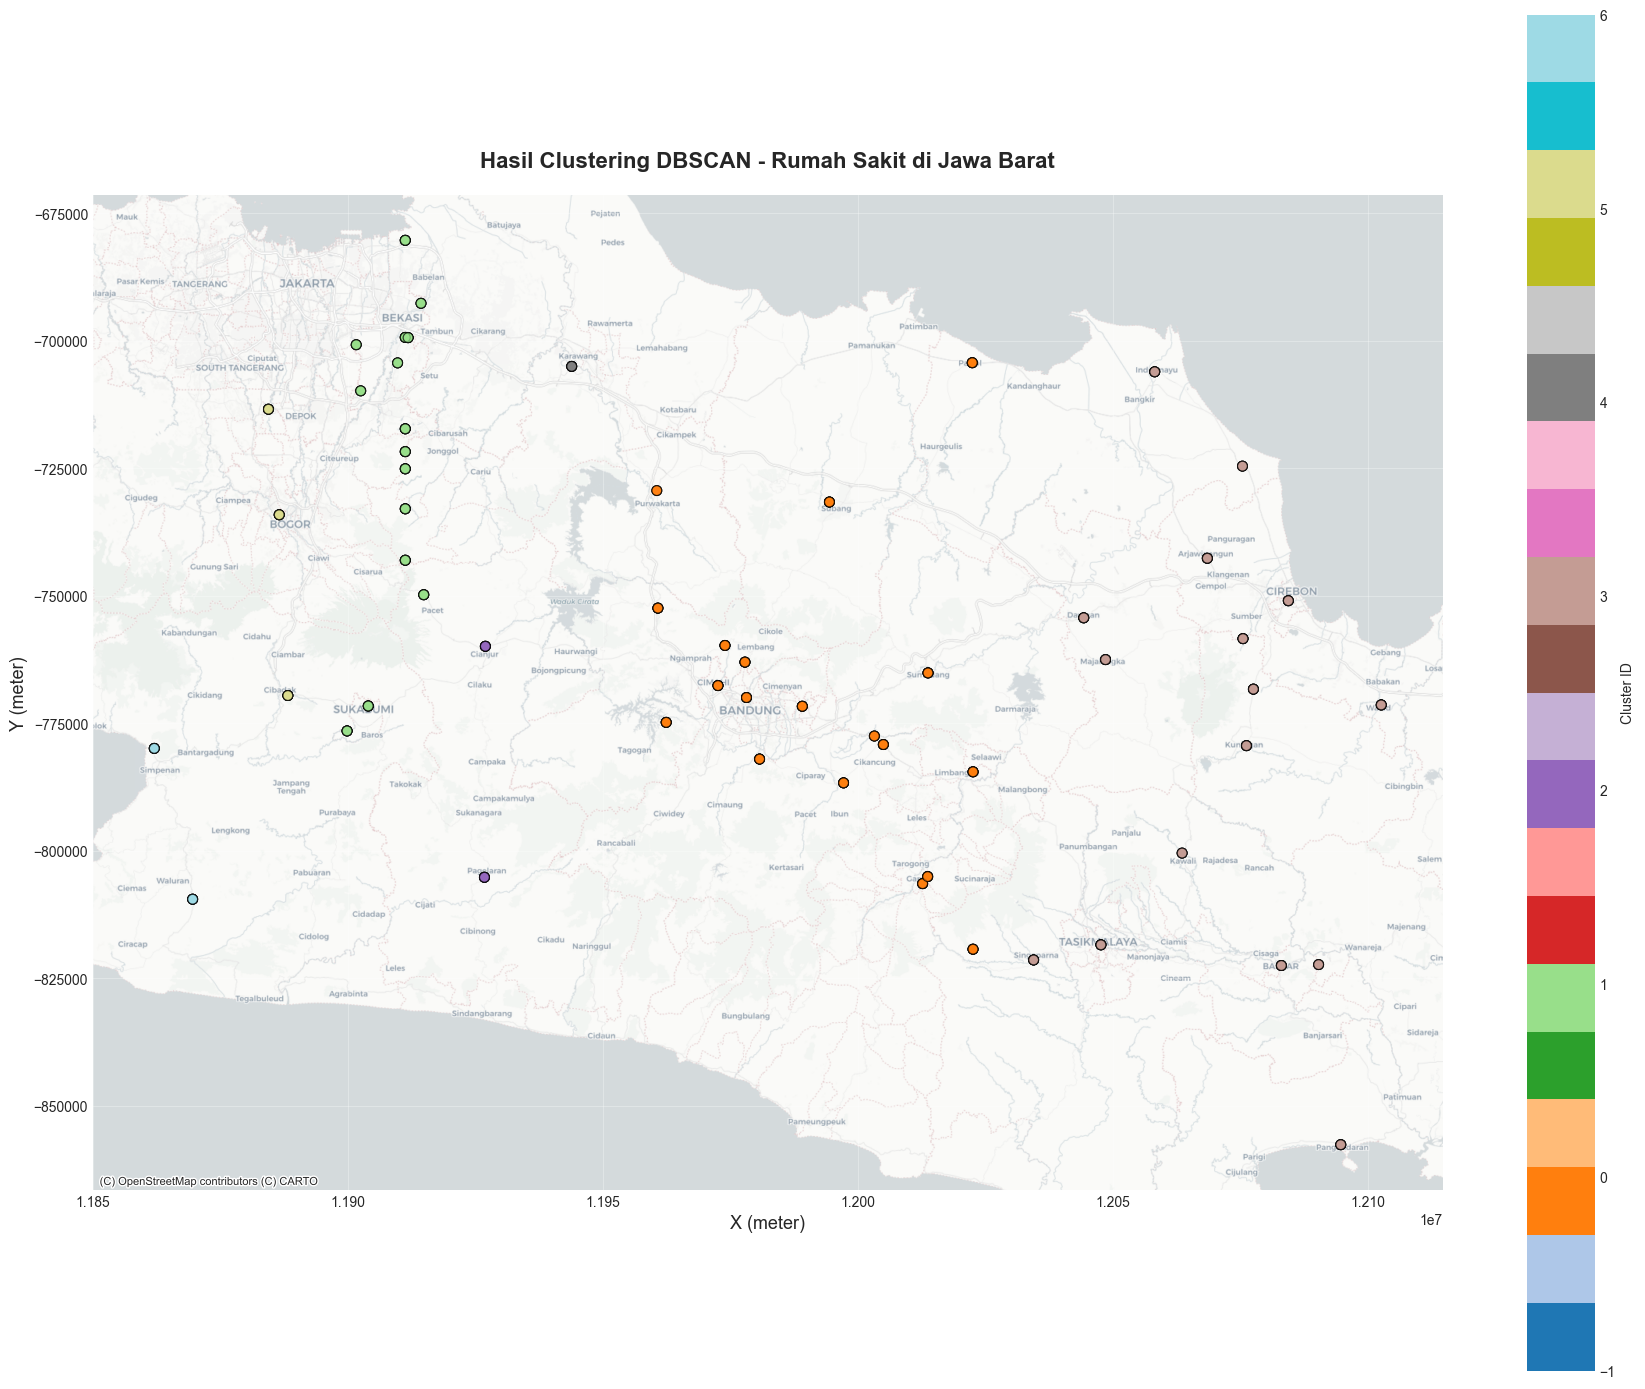

In [16]:
# Plot hasil clustering dengan basemap
fig, ax = plt.subplots(figsize=(18, 14))

# Konversi ke Web Mercator untuk basemap
gdf_web = gdf.to_crs(epsg=3857)

# Plot berdasarkan cluster
gdf_web.plot(column='Cluster', ax=ax, cmap='tab20', markersize=50, 
         alpha=0.7, edgecolor='black', linewidth=0.8, legend=True,
         legend_kwds={'label': 'Cluster ID', 'orientation': 'vertical'})

# Tambahkan basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=10)

ax.set_title('Hasil Clustering DBSCAN - Rumah Sakit di Jawa Barat', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('X (meter)', fontsize=13)
ax.set_ylabel('Y (meter)', fontsize=13)
ax.grid(True, alpha=0.3)

# Set aspect ratio
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

### 9.2. Peta Interaktif Hasil Clustering dengan Folium

In [17]:
# Buat peta interaktif dengan cluster
peta_cluster = folium.Map(location=[center_lat, center_lon], zoom_start=9)

# Warna untuk setiap cluster
colors = ['red', 'blue', 'green', 'purple', 'orange', 'darkred', 
          'lightred', 'beige', 'darkblue', 'darkgreen', 'cadetblue', 
          'darkpurple', 'pink', 'lightblue', 'lightgreen', 'gray', 'black']

# Tambahkan marker
for idx, row in df_clean.iterrows():
    cluster_id = row['Cluster']
    
    if cluster_id == -1:
        color = 'gray'
        icon = 'remove-sign'
    else:
        color = colors[cluster_id % len(colors)]
        icon = 'plus-sign'
    
    popup_text = f"""<b>{row['nama_rs']}</b><br>
                     <b>Cluster: {cluster_id}</b><br>
                     Kabupaten/Kota: {row['nama_kabupaten_kota']}<br>
                     Kecamatan: {row['kecamatan']}<br>
                     Alamat: {row['alamat']}"""
    
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=folium.Popup(popup_text, max_width=350),
        icon=folium.Icon(color=color, icon=icon),
        tooltip=f"Cluster {cluster_id}: {row['nama_rs']}"
    ).add_to(peta_cluster)

peta_cluster

### 9.3. Distribusi Cluster (Bar Chart)

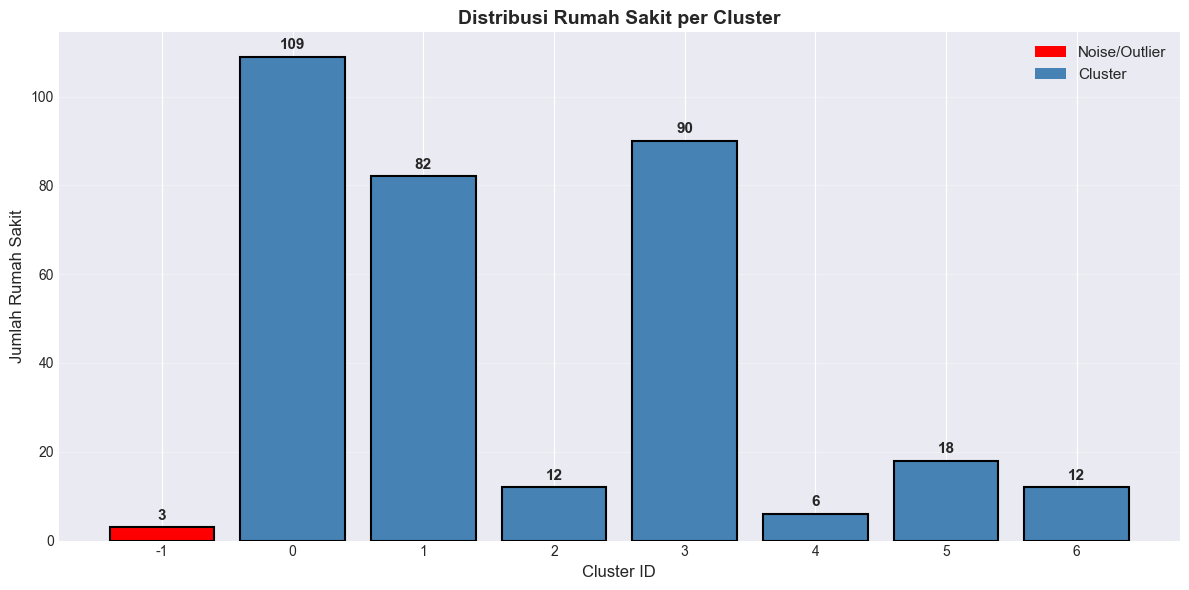

In [18]:
# Visualisasi distribusi cluster
cluster_counts = pd.Series(clusters).value_counts().sort_index()

plt.figure(figsize=(12, 6))
colors_bar = ['red' if idx == -1 else 'steelblue' for idx in cluster_counts.index]
bars = plt.bar(range(len(cluster_counts)), cluster_counts.values, color=colors_bar, edgecolor='black', linewidth=1.5)

plt.xlabel('Cluster ID', fontsize=12)
plt.ylabel('Jumlah Rumah Sakit', fontsize=12)
plt.title('Distribusi Rumah Sakit per Cluster', fontsize=14, fontweight='bold')
plt.xticks(range(len(cluster_counts)), cluster_counts.index)
plt.grid(True, alpha=0.3, axis='y')

# Tambahkan nilai di atas bar
for i, v in enumerate(cluster_counts.values):
    plt.text(i, v + 1, str(v), ha='center', va='bottom', fontweight='bold', fontsize=11)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='red', label='Noise/Outlier'),
                   Patch(facecolor='steelblue', label='Cluster')]
plt.legend(handles=legend_elements, loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

## 10. Analisis Karakteristik Cluster

In [19]:
# Analisis setiap cluster
print("="*80)
print("ANALISIS KARAKTERISTIK SETIAP CLUSTER")
print("="*80)

for cluster_id in sorted(set(clusters)):
    cluster_data = df_clean[df_clean['Cluster'] == cluster_id]
    
    if cluster_id == -1:
        print(f"\n{'='*80}")
        print(f"CLUSTER {cluster_id} (NOISE/OUTLIER)")
        print(f"{'='*80}")
    else:
        print(f"\n{'='*80}")
        print(f"CLUSTER {cluster_id}")
        print(f"{'='*80}")
    
    print(f"\nJumlah Rumah Sakit: {len(cluster_data)}")
    
    # Statistik lokasi
    print(f"\nStatistik Koordinat:")
    print(f"  Latitude  - Min: {cluster_data['latitude'].min():.6f}, Max: {cluster_data['latitude'].max():.6f}, Mean: {cluster_data['latitude'].mean():.6f}")
    print(f"  Longitude - Min: {cluster_data['longitude'].min():.6f}, Max: {cluster_data['longitude'].max():.6f}, Mean: {cluster_data['longitude'].mean():.6f}")
    
    # Distribusi per kabupaten/kota
    print(f"\nDistribusi per Kabupaten/Kota:")
    kab_dist = cluster_data['nama_kabupaten_kota'].value_counts().head(5)
    for kab, count in kab_dist.items():
        print(f"  {kab}: {count} RS")
    
    # Sample rumah sakit
    print(f"\nContoh Rumah Sakit dalam Cluster:")
    sample_rs = cluster_data[['nama_rs', 'nama_kabupaten_kota', 'kecamatan']].head(5)
    for idx, row in sample_rs.iterrows():
        print(f"  - {row['nama_rs']}")
        print(f"    Lokasi: {row['kecamatan']}, {row['nama_kabupaten_kota']}")
    
    if len(cluster_data) > 5:
        print(f"  ... dan {len(cluster_data) - 5} rumah sakit lainnya")

print(f"\n{'='*80}")

ANALISIS KARAKTERISTIK SETIAP CLUSTER

CLUSTER -1 (NOISE/OUTLIER)

Jumlah Rumah Sakit: 3

Statistik Koordinat:
  Latitude  - Min: -65381349.000000, Max: -65381349.000000, Mean: -65381349.000000
  Longitude - Min: 107.443049, Max: 107.443049, Mean: 107.443049

Distribusi per Kabupaten/Kota:
  KABUPATEN PURWAKARTA: 3 RS

Contoh Rumah Sakit dalam Cluster:
  - RSUD BAYU ASIH
    Lokasi:  PURWAKARTA, KABUPATEN PURWAKARTA
  - RSUD BAYU ASIH
    Lokasi:  PURWAKARTA, KABUPATEN PURWAKARTA
  - RSUD BAYU ASIH
    Lokasi:  PURWAKARTA, KABUPATEN PURWAKARTA

CLUSTER 0

Jumlah Rumah Sakit: 109

Statistik Koordinat:
  Latitude  - Min: -7.340000, Max: -6.314321, Mean: -6.909397
  Longitude - Min: 107.443000, Max: 108.000000, Mean: 107.739014

Distribusi per Kabupaten/Kota:
  KABUPATEN BANDUNG: 28 RS
  KABUPATEN BANDUNG BARAT: 24 RS
  KABUPATEN GARUT: 12 RS
  KOTA BANDUNG: 12 RS
  KABUPATEN INDRAMAYU: 6 RS

Contoh Rumah Sakit dalam Cluster:
  - RSUD CICALENGKA
    Lokasi: CICALENGKA, KABUPATEN BANDUNG
 

## 11. Export Hasil Clustering

In [20]:
# Export ke CSV
output_file = '../../Model/hasil_clustering_rs.csv'
df_clean.to_csv(output_file, index=False)
print(f"✅ Hasil clustering telah disimpan ke: {output_file}")

# Export ke GeoJSON
output_geojson = '../../Model/hasil_clustering_rs.geojson'
gdf.to_file(output_geojson, driver='GeoJSON')
print(f"✅ GeoJSON telah disimpan ke: {output_geojson}")

# Preview
print("\nPreview hasil clustering:")
df_clean[['nama_rs', 'nama_kabupaten_kota', 'kecamatan', 'latitude', 'longitude', 'Cluster']].head(15)

✅ Hasil clustering telah disimpan ke: ../../Model/hasil_clustering_rs.csv
✅ GeoJSON telah disimpan ke: ../../Model/hasil_clustering_rs.geojson

Preview hasil clustering:
✅ GeoJSON telah disimpan ke: ../../Model/hasil_clustering_rs.geojson

Preview hasil clustering:


,nama_rs,nama_kabupaten_kota,kecamatan,latitude,longitude,Cluster
0,RSUD CICALENGKA,KABUPATEN BANDUNG,CICALENGKA,-6.982337,107.842052,0
1,RSUD AL IHSAN,KABUPATEN BANDUNG,BALEENDAH,-7.007707,107.624064,0
2,RSUD MAJALAYA,KABUPATEN BANDUNG,PASEH,-7.049290,107.772000,0
3,RSUD SOREANG,KABUPATEN BANDUNG,SOREANG,-7.030000,108.000000,0
4,RSUD CIKALONG WETAN,KABUPATEN BANDUNG BARAT,CIKALONG WETAN,-6.743744,107.444976,0
5,RSUD LEMBANG,KABUPATEN BANDUNG BARAT,LEMBANG,-6.838210,107.598325,0
6,RSJ PROVINSI JAWA BARAT,KABUPATEN BANDUNG BARAT,CISARUA,-6.809015,107.563111,0
7,RSUD CILILIN,KABUPATEN BANDUNG BARAT,CILILIN,-6.943538,107.459616,0
8,RSUD KABUPATEN BEKASI,KABUPATEN BEKASI,CIBITUNG,-6.270000,107.000000,1
9,RSUD CABANGBUNGIN,KABUPATEN BEKASI,CABANGBUNGIN,-6.100000,107.000000,1


## 12. Ringkasan dan Kesimpulan

In [21]:
print("="*80)
print("RINGKASAN ANALISIS CLUSTERING DBSCAN")
print("RUMAH SAKIT DI JAWA BARAT")
print("="*80)

print(f"\n📊 DATASET:")
print(f"   Total Rumah Sakit: {len(df_clean)}")
print(f"   Total Kabupaten/Kota: {df_clean['nama_kabupaten_kota'].nunique()}")
print(f"   Provinsi: {df_clean['nama_provinsi'].unique()[0]}")

print(f"\n⚙️  PARAMETER DBSCAN:")
print(f"   Epsilon (eps): {eps}")
print(f"   Min Samples: {min_samples}")

print(f"\n🎯 HASIL CLUSTERING:")
print(f"   Jumlah Cluster: {n_clusters}")
print(f"   Noise Points: {n_noise} ({(n_noise/len(clusters)*100):.1f}%)")

if n_clusters_eval > 1:
    print(f"\n📈 EVALUASI:")
    print(f"   Silhouette Score: {silhouette:.4f}")
    print(f"   Davies-Bouldin Index: {davies_bouldin:.4f}")
    print(f"   Calinski-Harabasz Score: {calinski_harabasz:.4f}")

print(f"\n💡 INTERPRETASI:")
print(f"   DBSCAN berhasil mengelompokkan rumah sakit berdasarkan kedekatan geografis.")
print(f"   Cluster yang terbentuk menunjukkan konsentrasi rumah sakit di area tertentu.")
print(f"   Noise points menunjukkan rumah sakit yang terisolasi atau jauh dari kelompok.")

print(f"\n🎯 REKOMENDASI:")
print(f"   - Cluster dengan konsentrasi tinggi: Evaluasi kapasitas dan distribusi layanan")
print(f"   - Area dengan sedikit/tanpa cluster: Pertimbangkan penambahan fasilitas kesehatan")
print(f"   - Noise points: Perhatian khusus untuk aksesibilitas masyarakat")

print("="*80)

RINGKASAN ANALISIS CLUSTERING DBSCAN
RUMAH SAKIT DI JAWA BARAT

📊 DATASET:
   Total Rumah Sakit: 332
   Total Kabupaten/Kota: 27
   Provinsi: JAWA BARAT

⚙️  PARAMETER DBSCAN:
   Epsilon (eps): 0.15
   Min Samples: 5

🎯 HASIL CLUSTERING:
   Jumlah Cluster: 7
   Noise Points: 3 (0.9%)

📈 EVALUASI:
   Silhouette Score: 0.6079
   Davies-Bouldin Index: 0.3323
   Calinski-Harabasz Score: 979.2645

💡 INTERPRETASI:
   DBSCAN berhasil mengelompokkan rumah sakit berdasarkan kedekatan geografis.
   Cluster yang terbentuk menunjukkan konsentrasi rumah sakit di area tertentu.
   Noise points menunjukkan rumah sakit yang terisolasi atau jauh dari kelompok.

🎯 REKOMENDASI:
   - Cluster dengan konsentrasi tinggi: Evaluasi kapasitas dan distribusi layanan
   - Area dengan sedikit/tanpa cluster: Pertimbangkan penambahan fasilitas kesehatan
   - Noise points: Perhatian khusus untuk aksesibilitas masyarakat
